# 0. Data Review

10AWG, 24AWG CSV 파일을 읽고 데이터 요약과 전체 CFM 파형을 확인함

## 1. 데이터 읽기

In [10]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

# 데이터 경로
DATA_DIR = Path("data")
force_cols = [f"data{i}" for i in range(1, 201)]

# 본 코드에 사용할 CSV 파일
csv_files = ["10AWG.csv", "24AWG.csv"]

# CSV를 읽어서 저장함
datasets = {}
force_datasets = {}
for file_name in csv_files:
    csv_path = DATA_DIR / file_name
    name = csv_path.stem
    df = pd.read_csv(csv_path)
    force_df = df[force_cols].apply(pd.to_numeric, errors="coerce")

    datasets[name] = df
    force_datasets[name] = force_df

    print(f"{name}: {df.shape}")

10AWG: (199, 201)
24AWG: (199, 201)


## 2. 데이터 요약

In [16]:
# 데이터 샘플
for name, df in datasets.items():
    print(f"[{name}] 데이터 샘플")
    display(df.head())

# 파일별 통계
summary_rows = []

for name, df in datasets.items():
    force_df = force_datasets[name]
    label_count = df["Results"].value_counts().to_dict()

    summary_rows.append({
        "파일명": name,
        "샘플 수": len(df),
        "측정 포인트 수": len(force_cols),
        "최소값": force_df.min().min(),
        "최대값": force_df.max().max(),
        "평균값": force_df.to_numpy().mean(),
        "표준편차": force_df.to_numpy().std(),
        "g 개수": label_count.get("g", 0),
        "b 개수": label_count.get("b", 0),
        "f 개수": label_count.get("f", 0),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

[10AWG] 데이터 샘플


,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,...,data192,data193,data194,data195,data196,data197,data198,data199,data200,Results
0,9,13,15,20,27,33,66,100,130,164,...,0,0,0,0,0,0,0,0,0,g
1,56,51,82,88,104,106,123,128,150,180,...,0,0,0,0,0,0,0,0,0,g
2,36,36,46,58,64,76,89,97,105,123,...,0,0,0,0,0,0,0,0,0,g
3,63,64,67,80,76,86,94,105,117,137,...,0,0,0,0,0,0,0,0,0,g
4,35,29,32,38,49,50,57,72,100,124,...,0,0,0,0,0,0,0,0,0,g


[24AWG] 데이터 샘플


,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,...,data192,data193,data194,data195,data196,data197,data198,data199,data200,Results
0,13,21,35,56,93,110,148,187,239,274,...,0,0,0,0,0,0,20,7,15,g
1,33,52,53,69,87,105,128,165,198,257,...,0,0,0,0,0,0,0,0,8,g
2,36,55,65,92,130,148,168,214,254,292,...,0,0,0,0,2,3,6,2,16,g
3,0,0,7,19,35,52,77,124,161,197,...,14,14,11,15,8,3,0,0,0,g
4,0,23,26,45,66,91,116,170,214,258,...,0,0,0,0,0,0,0,0,0,g


,파일명,샘플 수,측정 포인트 수,최소값,최대값,평균값,표준편차,g 개수,b 개수,f 개수
0,10AWG,199,200,0,39566,17743.414573,14367.313694,176,14,9
1,24AWG,199,200,0,28535,8789.229095,8651.174162,156,24,19


## 3. 전체 CFM 파형 Plot

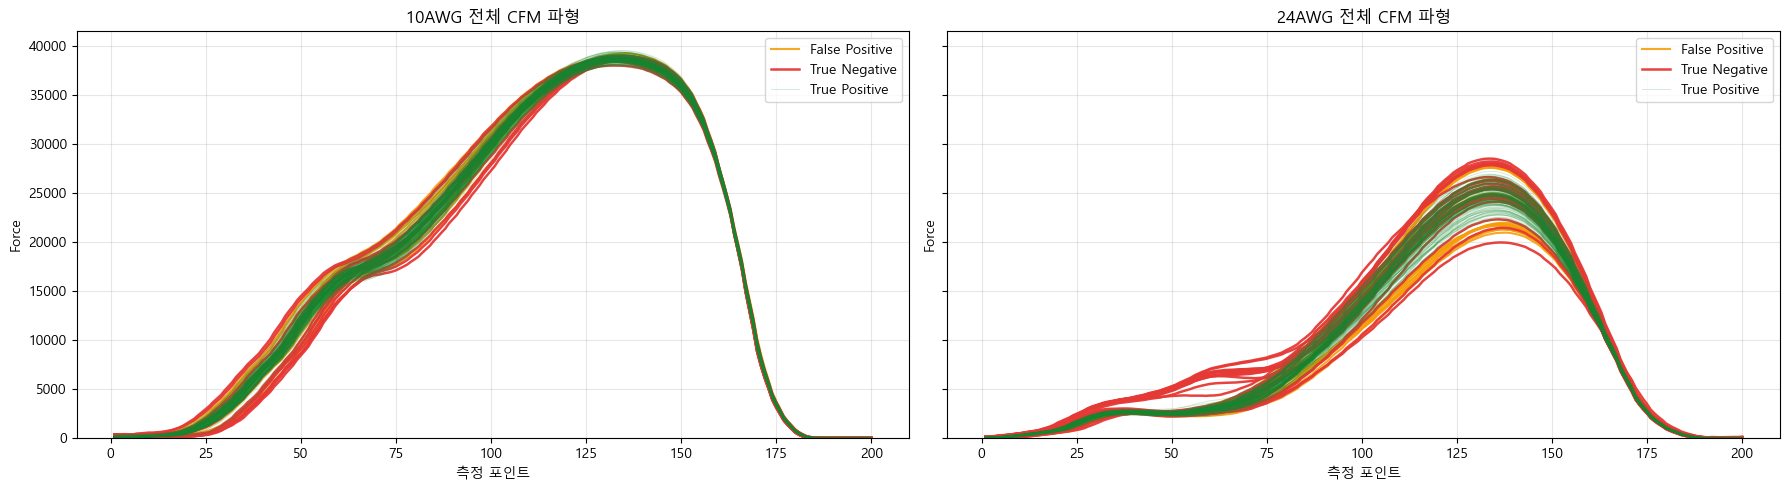

In [17]:
# 10AWG, 24AWG 전체 샘플 파형 
y_max = max(force_df.max().max() for force_df in force_datasets.values())

fig, axes = plt.subplots(1, len(datasets), figsize=(9 * len(datasets), 5), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, datasets.items()):
    force_df = force_datasets[name]


    # False Positive
    f_index = df[df["Results"] == "f"].index
    for i, idx in enumerate(f_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#f59e0b",
            alpha=0.9,
            linewidth=1.5,
            label="False Positive" if i == 0 else None,
        )

    # True Negative
    b_index = df[df["Results"] == "b"].index
    for i, idx in enumerate(b_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#e53935",
            alpha=0.95,
            linewidth=1.8,
            label="True Negative" if i == 0 else None,
        )
        
    # True Positive
    g_index = df[df["Results"] == "g"].index
    for i, idx in enumerate(g_index):
        ax.plot(
            range(1, 201),
            force_df.loc[idx].values,
            color="#168a2f",
            alpha=0.18,
            linewidth=0.7,
            label="True Positive" if i == 0 else None,
        )


    ax.set_title(f"{name} CFM WAVE")
    ax.set_xlabel("data point")
    ax.set_ylabel("Force")
    ax.set_ylim(0, y_max * 1.05)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()